# NYC Yellow Taxi -- Demand Forecasting EDA
**DSMA 2026 · Ben-Gurion University**



This notebook walks through the exploratory analysis and preparation of the NYC Yellow Taxi dataset for **Demand Forecasting**.
We follow a four-act structure to move from raw trip records to a clean, hourly aggregated demand dataset:

| Act | What we do |
|-----|------------|
| 1 -- Fundamentals | Understand the shape and meaning of the multi-year raw data |
| 2 -- Validation | Ask systematic questions: does the data meet our expectations? |
| 3 -- Cleaning | Fix what validation found and prepare for aggregation |
| 4 -- Transformation | Transforming the data into a time-series with aggregated demand |
| 4 -- EDA | Data-based storytelling & feature extraction |

**Objective:** Transition from individual trip records to predicting *Taxi Demand* (number of pickups) per zone and hour for 2024 and 2025.

***NOTE:*** To run the code in this notebook, please make sure all data between January 2024 to February 2026 (aka `yellow_tripdata_2024-01.parquet` - `yellow_tripdata_2026-02.parquet`) and the lookup file: `taxi_zone_lookup.csv` are all present in `data/raw`.

All files required can be downloaded here:
https://www.nyc.gov/site/tlc/about/tlc-trip-record-data.page

---

## Import Block

In [52]:
import sys
from pathlib import Path

# Add the project root to sys.path so we can import from src/
sys.path.insert(0, str(Path('.').resolve()))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import pyarrow.parquet as pq

# Set aesthetics to match course style
pd.set_option('display.max_columns', 30)
pd.set_option('display.float_format', '{:,.2f}'.format)
plt.rcParams['figure.figsize'] = (12, 5)
sns.set_theme(style="whitegrid")

---
## Act 1 -- Fundamentals
> **Goal:** Build a mental model of the raw data.
>
> Every row in this initial load represents **one taxi trip**. We need to verify the volume and schema before we begin our transformation into demand buckets.

In [53]:
DATA_DIR = 'data/raw'
all_files = [f for f in os.listdir(DATA_DIR) if f.endswith('.parquet') and f.startswith('yellow_tripdata_')]
all_files.sort()

# Include all files in data/raw 
train_files = [os.path.join(DATA_DIR, f) for f in all_files]

print(f"Loading {len(train_files)} parquet files...")

# Use ParquetDataset for robust multi-file loading
dataset = pq.ParquetDataset(train_files)
table = dataset.read(columns=['tpep_pickup_datetime', 'PULocationID'])
df = table.to_pandas()

print(f"Loaded {len(df):,} rows x {df.shape[1]} columns")
print(f"Memory usage: {df.memory_usage(deep=True).sum() / 1e6:.1f} MB")

Loading 26 parquet files...
Loaded 97,017,077 rows x 2 columns
Memory usage: 1164.2 MB


In [54]:
# Three sample rows -- (a sanity check)
df.head(3)

,tpep_pickup_datetime,PULocationID
0,2024-01-01 00:57:55,186
1,2024-01-01 00:03:00,140
2,2024-01-01 00:17:06,236


Notice that we only loaded `tpep_pickup_datetime` and `PULocationID`, since these are the only 2 relevant columns for predicting the demand in a specific location and time window.

In [55]:
# Summary statistics for every numeric column
# Look for: surprising min/max values, large std relative to mean, suspicious zeros
df.describe()

,tpep_pickup_datetime,PULocationID
count,97017077,"97,017,077.00"
mean,2025-02-16 17:31:30.014581,162.65
min,2002-12-31 16:46:07,1.00
25%,2024-08-08 21:29:54,125.00
50%,2025-03-02 22:12:38,161.00
75%,2025-09-01 13:27:29,233.00
max,2026-06-26 23:53:12,265.00
std,NaN,65.50


In [56]:
# Schema: column names, dtypes, and non-null counts at a glance
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 97017077 entries, 0 to 97017076
Data columns (total 2 columns):
 #   Column                Dtype         
---  ------                -----         
 0   tpep_pickup_datetime  datetime64[us]
 1   PULocationID          int32         
dtypes: datetime64[us](1), int32(1)
memory usage: 1.1 GB


### What does one row represent?

A single row represents one taxi trip:

| Column group | What it captures |
|---|---|
| `tpep_pickup_datetime` | When the trip started
| `PULocationID` | Pickup taxi zones (1-265) |

---
## Act 2 -- Data Validation
> **Goal:** Replace vague intuition with precise, repeatable checks.
>
> We will build three check types from scratch, 
> then run the full suite from `src/validation.py`.

#### Check type 1

In [57]:
# Check type 1: nullability
def check_not_null(df, col):
    n_null = df[col].isna().sum()
    passed = int(n_null) == 0
    detail = 'OK' if passed else f'{n_null:,} nulls ({n_null / len(df):.2%} of rows)'
    return {'name': 'not_null', 'column': col, 'passed': passed, 'detail': detail}


Let's search for null values in our dataset

In [58]:
check_not_null(df, 'tpep_pickup_datetime')

{'name': 'not_null',
 'column': 'tpep_pickup_datetime',
 'passed': True,
 'detail': 'OK'}

In [59]:
check_not_null(df, 'PULocationID')

{'name': 'not_null', 'column': 'PULocationID', 'passed': True, 'detail': 'OK'}

No null values in our dataset. 

#### Check type 2

In [60]:
# Path 
lookup_file_path = 'data/raw/taxi_zone_lookup.csv'

# Load the dataset
df_lookup = pd.read_csv(lookup_file_path)

# Drop 'LocationID' and count unique values for the remaining columns
# .nunique() returns a Series with column names as indices
unique_counts = df_lookup.drop(columns=['LocationID']).nunique()

df_lookup.tail(2)

,LocationID,Borough,Zone,service_zone
263,264,Unknown,NaN,NaN
264,265,NaN,Outside of NYC,NaN


Looking at `taxi_zone_lookup.csv`, both LocationID 264 and LocationID 265 are classifed as unknown locations and will not provide any insight to our model. Let's see if our data holds rows with those LocationIDs.

In [61]:
# Check type 2: value range
def check_between(df, col, min_value=None, max_value=None):
    mask = pd.Series(True, index=df.index)
    if min_value is not None:
        mask &= df[col] >= min_value
    if max_value is not None:
        mask &= df[col] <= max_value
    fail_rate = (~mask & df[col].notna()).mean()
    passed    = fail_rate == 0
    detail    = 'OK' if passed else f'{fail_rate:.2%} of rows outside [{min_value}, {max_value}]'
    return {'name': f'between[{min_value},{max_value}]', 'column': col, 'passed': passed, 'detail': detail}


# Location IDs must be within the valid NYC zone range (1-263)
check_between(df, 'PULocationID', min_value=1, max_value=263)

{'name': 'between[1,263]',
 'column': 'PULocationID',
 'passed': np.False_,
 'detail': '0.27% of rows outside [1, 263]'}

#### Check type 3

In [62]:
# Check type 3: year range
def _check_min_year(df, col, min_year):
    years     = df[col].dt.year.unique()
    invalid   = [y for y in years if y < min_year]
    passed    = len(invalid) == 0
    detail    = 'OK' if passed else f'invalid years found: {invalid}'
    return {'name': f'year_at_least({min_year})', 'column': col, 'passed': passed, 'detail': detail}

# Check strictly for years 2024 and above
_check_min_year(df, 'tpep_pickup_datetime', min_year=2024)


{'name': 'year_at_least(2024)',
 'column': 'tpep_pickup_datetime',
 'passed': False,
 'detail': 'invalid years found: [np.int32(2023), np.int32(2009), np.int32(2002), np.int32(2008), np.int32(2007)]'}

### Packaging checks into a reusable module

We have moved these patterns into `src/validation.py`. For demand forecasting, we've also added a specific **Year Range Check** to ensure our data is strictly from 2024 and above.

In [63]:
from src.validation import validate_nyc_taxi_parquet

# Running the full suite on the first training file as a representative sample
report   = validate_nyc_taxi_parquet(train_files[0])
passed_n = sum(r['passed'] for r in report['results'])
total_n  = len(report['results'])
status   = 'ALL PASSED' if report['success'] else 'SOME CHECKS FAILED'
print(f'Result: {status}  ({passed_n}/{total_n} checks passed)')

Result: SOME CHECKS FAILED  (1/3 checks passed)


---
## Act 3 -- Data Cleaning
> **Goal:** produce a clean dataframe ready for analysis.
>
>
> We write the clean dataset to `data/processed/` so Act 4 and future
> notebooks can use it without re-running the cleaning steps.

We'll remove any rows that don't pass our 3 validation checks in Act 2. Reason for removal, per check:
* If `PULocationID` or `tpep_pickup_datetime` are null, we won't have enough information to intellegently impute new values in these rows.
* If `PULocationID` = 264 or 265, then the location for these rows are unknown / outside of NYC. Therefore, we won't be able to use these rows to predict the demand in any of the locations in NYC.
* If the year of `tpep_pickup_datetime` is earlier than 2024, we assume these rows are were put in our dataset by mistake.

In [64]:
# Act 3 -- Cleaning

# 1. Drop rows with nulls in critical columns
df = df.dropna(subset=['tpep_pickup_datetime', 'PULocationID'])

# 2. Filter to valid NYC Taxi Zones (1-263)
# This removes 'Unknown' (264) and 'Outside NYC' (265) which don't help prediction
df = df[df['PULocationID'].between(1, 263)]

# 3. Restrict to the 2024 and above period
df = df[df['tpep_pickup_datetime'].dt.year >= 2024]


print(f"Cleaned dataset size: {len(df):,}")

# Save the clean dataset to data/processed/
from pathlib import Path
DATA_PROCESSED = Path('data') / 'processed'
DATA_PROCESSED.mkdir(parents=True, exist_ok=True)
OUT_FILE       = DATA_PROCESSED / 'yellow_tripdata_2024-2026_cleaned.parquet'

# Save to parquet
df.to_parquet(OUT_FILE, index=False)
print(f'Saved --> {OUT_FILE}')

# Sanity check
df.head(3)


Cleaned dataset size: 96,756,824
Saved --> data\processed\yellow_tripdata_2024-2026_cleaned.parquet


,tpep_pickup_datetime,PULocationID
0,2024-01-01 00:57:55,186
1,2024-01-01 00:03:00,140
2,2024-01-01 00:17:06,236


### Packaging cleaning into a reusable module

We have moved the cleaning logic (null handling and date filtering) into `src/cleaning.py`. This ensures that our data preparation is consistent and reproducible across all notebooks and the production pipeline.

---
## Act 4 -- Transformation 
> **Goal:** Transform the dataset so each row represents the demand in a specific location and time-window.
>
> In demand forecasting, we don't care about individual trips—we care about the **count** of trips in a specific location and time-window . This is why we will transform our dataset into a time-series dataset.

### Demand Aggregation Strategy
To move from individual trips to a time-series format, we aggregate demand into **30-minute buckets**, per location. 
We use a standard rounding logic to assign each trip to the nearest 30-minute mark:
1. **[00 - 15 mins):** Rounded down to the **top of the hour** (e.g., 20:02 $\rightarrow$ 20:00).
2. **[15 - 45 mins):** Rounded to the **half-hour** mark (e.g., 20:17 $\rightarrow$ 20:30).
3. **[45 - 60 mins):** Rounded up to the **next hour** (e.g., 20:46 $\rightarrow$ 21:00).

This ensures we capture demand in granular slots, providing a balanced 30-minute distribution.

Additionally, we will:
* Filter out the data from 2026, since we'll want to perform the EDA only on the training set (aka data from 2024-2025).
* Add 3 basic time features to each row: `hour`, `day_of_week`, `month`.


In [65]:
# --- 4.0 The Transformation Logic ---

# Filter to Training Period (2024-2025) for EDA
print("Filtering to training period (2024-2025)...")
df_train = df[df['tpep_pickup_datetime'].dt.year <= 2025].copy()

# Pre-calculate the 30-minute smart buckets for aggregation
# Using .round('30min') implements the [0,15)->:00, [15,45)->:30, [45,60)->:00 logic correctly
df_train['pickup_datetime'] = df_train['tpep_pickup_datetime'].dt.round('30min')

print("Aggregating observed demand (30-min buckets)...")
demand_df = df_train.groupby(['pickup_datetime', 'PULocationID']).size().reset_index(name='demand')

print("Generating complete Time/Location grid to capture zero-demand...")
all_hours = pd.date_range(start='2024-01-01', end='2025-12-31 23:30:00', freq='30min')
all_locations = sorted(df_train['PULocationID'].unique())
multi_index = pd.MultiIndex.from_product([all_hours, all_locations], names=['pickup_datetime', 'PULocationID'])

demand_df = demand_df.set_index(['pickup_datetime', 'PULocationID']).reindex(multi_index, fill_value=0).reset_index()

# Add time features
demand_df['hour'] = demand_df['pickup_datetime'].dt.hour
demand_df['day_of_week'] = (demand_df['pickup_datetime'].dt.dayofweek + 1) % 7 + 1
demand_df['month'] = demand_df['pickup_datetime'].dt.month

print(f"Final Aggregated Shape: {demand_df.shape}")

# Sanity check (Forcing display of full timestamp including 00:00:00)
demand_df.assign(pickup_datetime=demand_df['pickup_datetime'].dt.strftime('%Y-%m-%d %H:%M:%S')).head(5)

Filtering to training period (2024-2025)...
Aggregating observed demand (30-min buckets)...
Generating complete Time/Location grid to capture zero-demand...
Final Aggregated Shape: (9157968, 6)


,pickup_datetime,PULocationID,demand,hour,day_of_week,month
0,2024-01-01 00:00:00,1,0,0,2,1
1,2024-01-01 00:00:00,2,0,0,2,1
2,2024-01-01 00:00:00,3,0,0,2,1
3,2024-01-01 00:00:00,4,3,0,2,1
4,2024-01-01 00:00:00,5,0,0,2,1


### Packaging transformation into a reusable module

We have moved the transformation logic (30-min aggregation and grid reindexing) into `src/transform_to_demand.py`. This ensures that our data preparation is consistent and reproducible across all notebooks and the production pipeline.

Now, each row in the dataset represents the demand in a specific location and time-window.

---
## Act 5 -- Exploratory Data Analysis
> **Goal:** find the stories hidden in the data.
>
> During the EDA, we will add features that seem important to the dataset as we progress.

Before we jump into plotting graphs and analyzing, let's use `taxi_zone_lookup.csv` to extract additional information that will enhance our EDA.

In [66]:
unique_counts = df_lookup.drop(columns=['LocationID']).nunique()

print("Unique values per column (excluding LocationID):")
print(unique_counts)

Unique values per column (excluding LocationID):
Borough           7
Zone            261
service_zone      4
dtype: int64


The `taxi_zone_lookup.csv` reveals a significant disparity in granularity across the available geographic features:

* Zone ID (High Cardinality): With 261 unique values across 265 locations, the Zone column provides nearly 1:1 mapping with the raw LocationID. 
* Borough & Service Zone (Low Cardinality): In contrast, Borough (7 unique values) and service_zone (4 unique values) offer a strategic level of aggregation.

To improve model generalization and reduce dimensionality, we will perform a left join to append Borough and service_zone to our primary dataset. This transformation allows the model to capture regional demand patterns (e.g., Manhattan vs. Queens) and functional service differences (e.g., Airports vs. EWR) rather than treating each specific zone as an isolated entity.

In [67]:

print("Creating enriched dataset: new_demand_df...")

# Select only the necessary columns from the lookup table
lookup_subset = df_lookup[['LocationID', 'Borough', 'service_zone']]

# Merge demand_df with the lookup metadata into a new object
new_demand_df = demand_df.merge(
    lookup_subset, 
    left_on='PULocationID', 
    right_on='LocationID', 
    how='left'
).drop(columns=['LocationID'])

# Fill any missing values (e.g., for LocationID 264/265 which are often 'Unknown')
new_demand_df['Borough'] = new_demand_df['Borough'].fillna('Unknown')
new_demand_df['service_zone'] = new_demand_df['service_zone'].fillna('Unknown')

print("Enrichment complete. New DataFrame created.")
print(f"Columns in new_demand_df: {new_demand_df.columns.tolist()}")

# Sanity check
new_demand_df.head(5)

Creating enriched dataset: new_demand_df...
Enrichment complete. New DataFrame created.
Columns in new_demand_df: ['pickup_datetime', 'PULocationID', 'demand', 'hour', 'day_of_week', 'month', 'Borough', 'service_zone']


,pickup_datetime,PULocationID,demand,hour,day_of_week,month,Borough,service_zone
0,2024-01-01,1,0,0,2,1,EWR,EWR
1,2024-01-01,2,0,0,2,1,Queens,Boro Zone
2,2024-01-01,3,0,0,2,1,Bronx,Boro Zone
3,2024-01-01,4,3,0,2,1,Manhattan,Yellow Zone
4,2024-01-01,5,0,0,2,1,Staten Island,Boro Zone


The `service_zone` column has both the value "EWR" (specifically for Newark Airport) and the value "Airports" (for other airports in NYC). To help the model better capture generalized airport demand patterns, we will merge these categories by replacing all "EWR" values with "Airports".  

In [68]:
print("Merging 'EWR' into 'Airports' service_zone...")

# Replace 'EWR' with 'Airports' in the service_zone column
new_demand_df['service_zone'] = new_demand_df['service_zone'].replace('EWR', 'Airports')

# Verification: Check the unique values to ensure EWR is gone
remaining_categories = new_demand_df['service_zone'].unique()
print(f"Updated service_zone categories: {remaining_categories}")

# Sanity check for the first few rows (LocationID 1 should now show 'Airports')
new_demand_df.head(5)

Merging 'EWR' into 'Airports' service_zone...
Updated service_zone categories: ['Airports' 'Boro Zone' 'Yellow Zone']


,pickup_datetime,PULocationID,demand,hour,day_of_week,month,Borough,service_zone
0,2024-01-01,1,0,0,2,1,EWR,Airports
1,2024-01-01,2,0,0,2,1,Queens,Boro Zone
2,2024-01-01,3,0,0,2,1,Bronx,Boro Zone
3,2024-01-01,4,3,0,2,1,Manhattan,Yellow Zone
4,2024-01-01,5,0,0,2,1,Staten Island,Boro Zone


### 5.1 Temporal Trends: Monthly Volume
How does NYC taxi demand change over the two-year period?

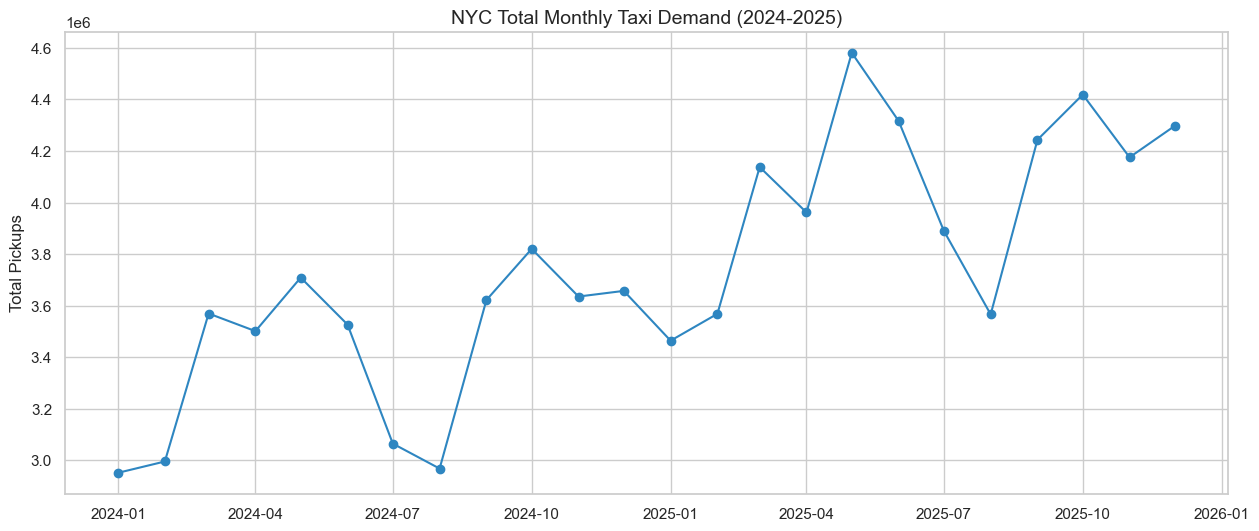

In [69]:
monthly_demand = new_demand_df.groupby(new_demand_df['pickup_datetime'].dt.to_period('M'))['demand'].sum()
monthly_demand.index = monthly_demand.index.to_timestamp()

plt.figure(figsize=(15, 6))
plt.plot(monthly_demand.index, monthly_demand.values, marker='o', linestyle='-', color='#2E86C1')
plt.title('NYC Total Monthly Taxi Demand (2024-2025)', fontsize=14)
plt.ylabel('Total Pickups')
plt.show()

> **The Story:** NYC taxi demand shows a distinct seasonal pattern. We see peaks in the spring and autumn, with significant dips during late summer and the holiday season. The 2025 data shows a slight but steady recovery compared to early 2024, indicating that the city's "heartbeat" is strengthening. This confirms that **Month** will be a key feature for our model.

### 5.2 The Weekly Rhythm
How does demand pulse through a typical week?

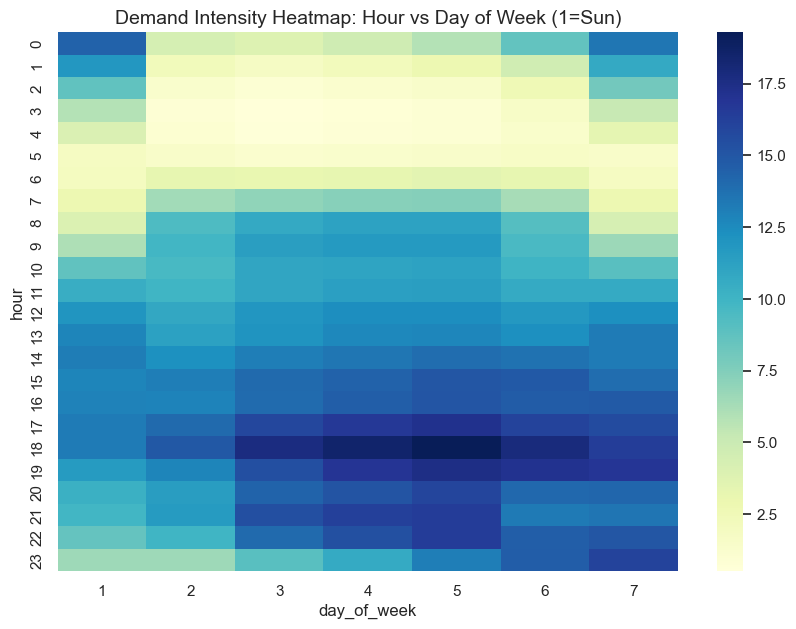

In [70]:
heatmap_data = new_demand_df.groupby(['hour', 'day_of_week'])['demand'].mean().unstack()
plt.figure(figsize=(10, 7))
sns.heatmap(heatmap_data, cmap='YlGnBu')
plt.title('Demand Intensity Heatmap: Hour vs Day of Week (1=Sun)', fontsize=14)
plt.show()

> **The Story:** Taxi demand in New York follows clear weekly behavioral patterns. We see heavy morning and evening rush hours during the work week (Monday-Friday), while weekends show a shifted pattern with late-night peaks on Saturday and Sunday. This “checkerboard” pattern suggests that both Hour and Day of Week carry strong predictive value for taxi demand forecasting.

### 5.3 Geographic Trends: Demand by Borough
How is taxi demand distributed across the different boroughs of NYC?

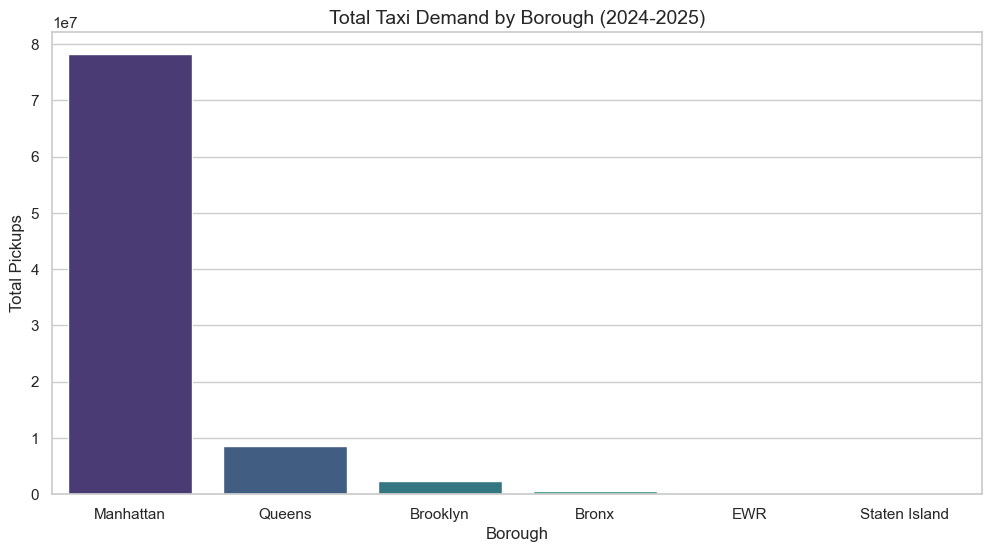

In [71]:
borough_demand = new_demand_df.groupby('Borough')['demand'].sum().sort_values(ascending=False)

plt.figure(figsize=(12, 6))
sns.barplot(x=borough_demand.index, y=borough_demand.values, hue=borough_demand.index, palette='viridis', legend=False)
plt.title('Total Taxi Demand by Borough (2024-2025)', fontsize=14)
plt.ylabel('Total Pickups')
plt.xlabel('Borough')
plt.show()

> **The Story:** Manhattan is the undisputed heart of NYC's taxi activity, accounting for the vast majority of pickups. There's also a moderate demand in Brooklyn and Queens (most likely driven by the airports) shows that these are also vital regions. This plot confirms that **Borough** is a powerful aggregator for regional demand.

### 5.4 Functional Zones: Demand by Service Zone
Does the type of service zone (Airport vs. Boro vs. Yellow) influence demand volume?

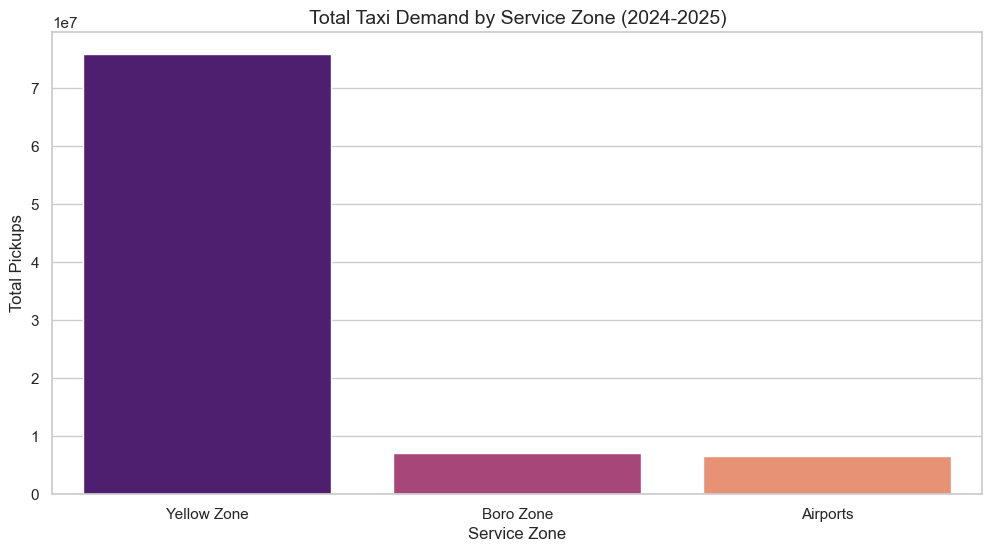

In [72]:
sz_demand = new_demand_df.groupby('service_zone')['demand'].sum().sort_values(ascending=False)

plt.figure(figsize=(12, 6))
sns.barplot(x=sz_demand.index, y=sz_demand.values, hue=sz_demand.index, palette='magma', legend=False)
plt.title('Total Taxi Demand by Service Zone (2024-2025)', fontsize=14)
plt.ylabel('Total Pickups')
plt.xlabel('Service Zone')
plt.show()

> **The Story:** The Yellow Zone dominates NYC taxi demand, outperforming Boro Zones and Airports by a factor of nearly ten. This extreme concentration suggests that while the Airports and Boro Zones are vital for specific travel types, the vast majority of ride-hailing activity remains centered in Manhattan's core business and tourist districts.

### 5.5 Top Locations by Demand
Which specific locations are the primary drivers of taxi volume in New York?

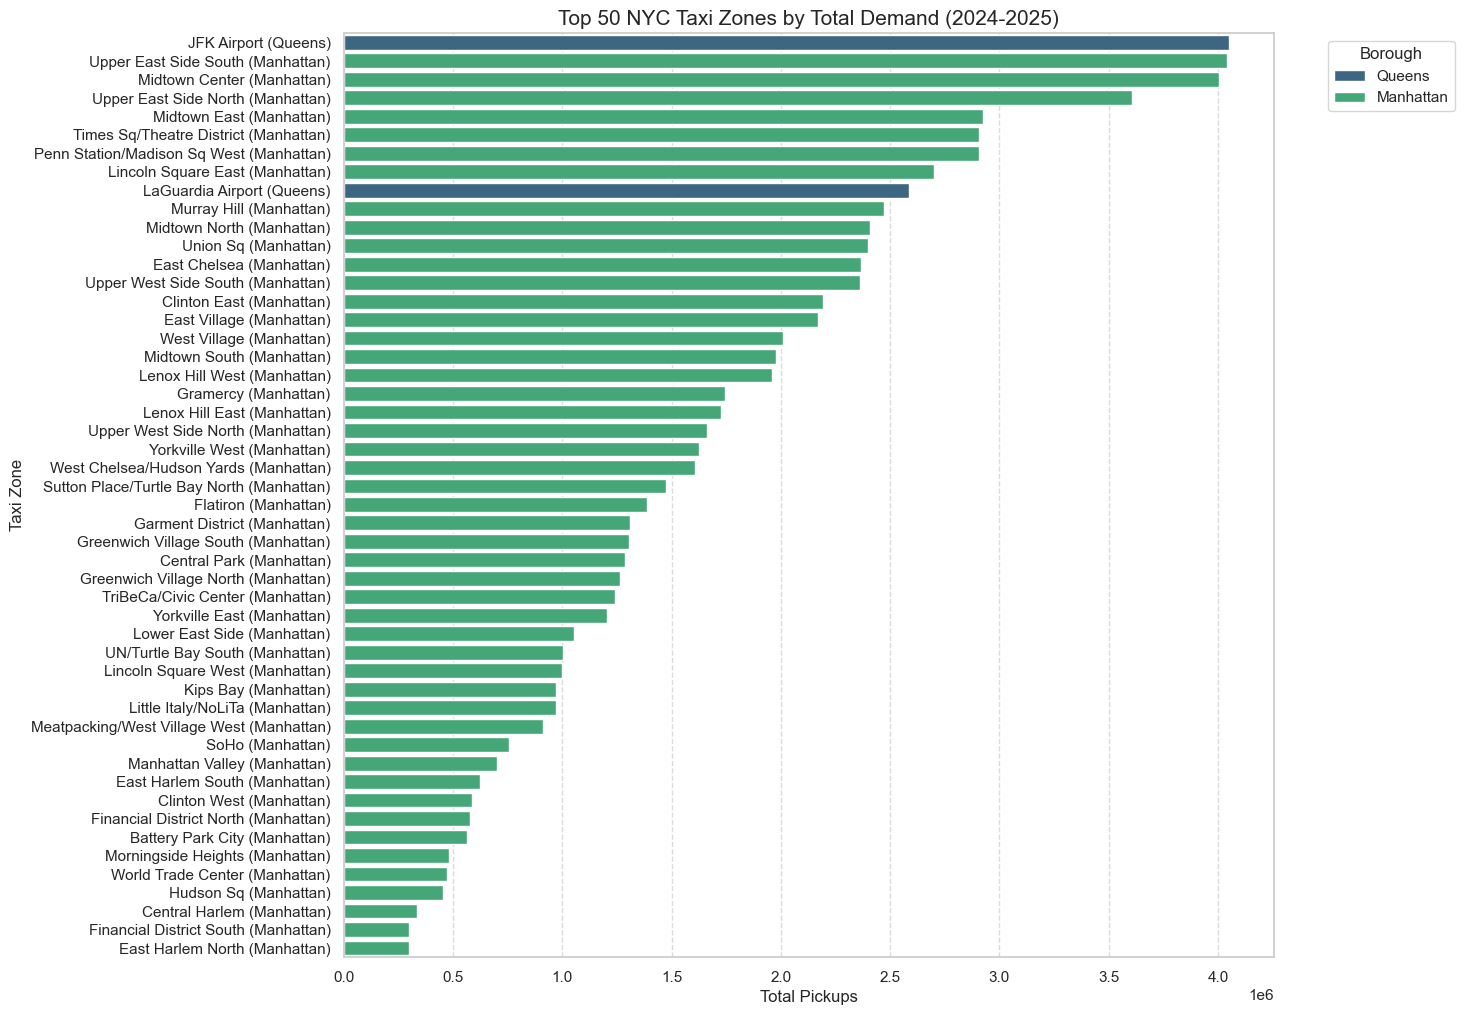

In [73]:
# 1. Aggregate total demand by Location
top_50_demand = new_demand_df.groupby('PULocationID')['demand'].sum().sort_values(ascending=False).head(50).reset_index()

# 2. Join with lookup table to get human-readable Zone names
top_50_zones = top_50_demand.merge(df_lookup[['LocationID', 'Zone', 'Borough']], left_on='PULocationID', right_on='LocationID')

# 3. Create descriptive label combining Zone and Borough
top_50_zones['LocationLabel'] = top_50_zones['Zone'] + ' (' + top_50_zones['Borough'] + ')'

# 4. Visualization
plt.figure(figsize=(12, 12))
sns.barplot(data=top_50_zones, x='demand', y='LocationLabel', hue='Borough', palette='viridis', dodge=False)
plt.title('Top 50 NYC Taxi Zones by Total Demand (2024-2025)', fontsize=15)
plt.xlabel('Total Pickups')
plt.ylabel('Taxi Zone')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.legend(title='Borough', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

> **The Story:** While Manhattan dominates the city's overall volume, the data reveals a high degree of geographic concentration - a handful of "Power Zones", mostly in Midtown and Lower Manhattan, act as the primary engines of the taxi economy. 

### 5.6 The Nightlife Surge
Let's look at the rows with the highest demand in our dataset and see what we can understand from it.

In [74]:
# Discovery: Looking at the top 50 demand spikes in the dataset enriched with Zone names
lookup = pd.read_csv('data/raw/taxi_zone_lookup.csv')
(
    new_demand_df.sort_values('demand', ascending=False)
    .head(50)
    .merge(lookup[['LocationID', 'Zone']], left_on='PULocationID', right_on='LocationID')
    .drop(columns=['LocationID'])
)

,pickup_datetime,PULocationID,demand,hour,day_of_week,month,Borough,service_zone,Zone
0,2025-11-02 01:30:00,79,698,1,1,11,Manhattan,Yellow Zone,East Village
1,2024-11-03 01:30:00,79,644,1,1,11,Manhattan,Yellow Zone,East Village
2,2025-02-02 01:00:00,79,544,1,1,2,Manhattan,Yellow Zone,East Village
3,2025-02-02 01:30:00,79,529,1,1,2,Manhattan,Yellow Zone,East Village
4,2024-11-03 01:00:00,79,523,1,1,11,Manhattan,Yellow Zone,East Village
5,2025-09-14 01:30:00,79,522,1,1,9,Manhattan,Yellow Zone,East Village
6,2025-03-02 00:30:00,79,517,0,1,3,Manhattan,Yellow Zone,East Village
7,2025-03-23 01:00:00,79,506,1,1,3,Manhattan,Yellow Zone,East Village
8,2025-01-26 01:00:00,79,501,1,1,1,Manhattan,Yellow Zone,East Village
9,2025-12-07 02:00:00,79,500,2,1,12,Manhattan,Yellow Zone,East Village


Notice the pattern above: The top spikes are almost exclusively in **Location 79 (East Village)** during the late night hours of Fridays, Saturdays, and Sundays. To help the model capture this unique signature, we've engineered two specialized features:

1. **`is_nightlife_surge`**: A binary flag for weekend nights (Fri-Sun, 22:00-04:00) in known nightlife hotspots (West Village, Lincoln Square East, etc.). This captures the general "party" trend across Manhattan.
2. **`is_east_village_surge`**: A dedicated flag specifically for the East Village (Zone 79) during the same weekend night window. 

The motivation for separating these features is clear from the data: demand spikes in the East Village frequently exceed 400 rides, substantially higher than those observed in other nightlife hubs. By isolating Location 79, the model can learn its uniquely high-intensity demand pattern without averaging it together with lower-volume nightlife zones.

In [75]:
# Nightlife Hotspots identified during analysis
nightlife_hubs = [142, 249, 114, 125, 211]
east_village = 79

# Idempotent feature creation
if 'is_nightlife_surge' not in new_demand_df.columns:
    new_demand_df['is_nightlife_surge'] = (
        (new_demand_df['PULocationID'].isin(nightlife_hubs)) &
        (new_demand_df['day_of_week'].isin([4, 5, 6])) &
        ((new_demand_df['hour'] >= 22) | (new_demand_df['hour'] <= 4))
    ).astype(int)

if 'is_east_village_surge' not in new_demand_df.columns:
    new_demand_df['is_east_village_surge'] = (
        (new_demand_df['PULocationID'] == east_village) &
        (new_demand_df['day_of_week'].isin([4, 5, 6])) &
        ((new_demand_df['hour'] >= 22) | (new_demand_df['hour'] <= 4))
    ).astype(int)

new_demand_df.head()

,pickup_datetime,PULocationID,demand,hour,day_of_week,month,Borough,service_zone,is_nightlife_surge,is_east_village_surge
0,2024-01-01,1,0,0,2,1,EWR,Airports,0,0
1,2024-01-01,2,0,0,2,1,Queens,Boro Zone,0,0
2,2024-01-01,3,0,0,2,1,Bronx,Boro Zone,0,0
3,2024-01-01,4,3,0,2,1,Manhattan,Yellow Zone,0,0
4,2024-01-01,5,0,0,2,1,Staten Island,Boro Zone,0,0


These specialized features will give the model the 'permission' it needs to predict extreme demand during weekends.

### 5.7 The Month Phase Pattern
Let's look at how the phase of the month impacts hourly demand patterns.

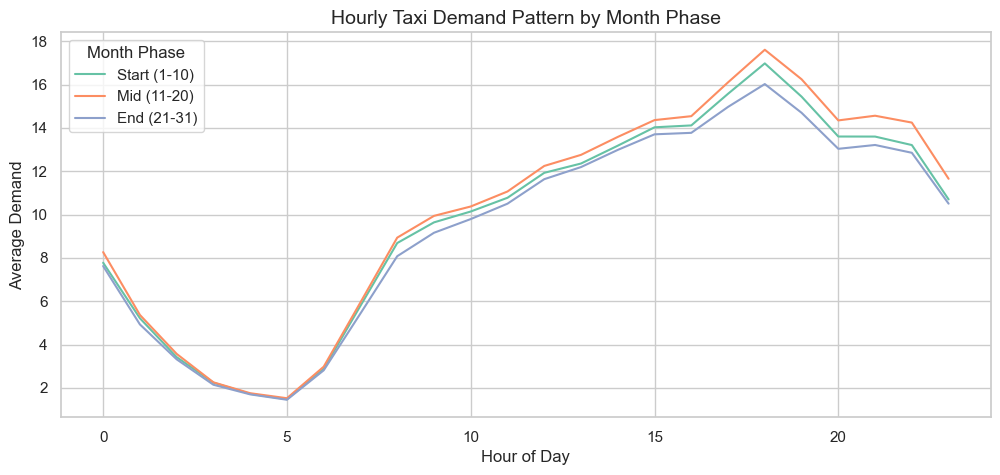

In [77]:
# 1. Calculate month phases
month_phases = pd.cut(
    new_demand_df['pickup_datetime'].dt.day, 
    bins=[0, 10, 20, 31], 
    labels=['Start (1-10)', 'Mid (11-20)', 'End (21-31)']
)

# 2. Plot the hourly demand pattern, passing the series directly to 'hue'
plt.figure(figsize=(12, 5))
sns.lineplot(
    data=new_demand_df, 
    x='hour', 
    y='demand', 
    hue=month_phases, 
    errorbar=None, 
    palette='Set2'
)
plt.title('Hourly Taxi Demand Pattern by Month Phase', fontsize=14)
plt.xlabel('Hour of Day')
plt.ylabel('Average Demand')
plt.legend(title='Month Phase')
plt.show()


* **Identical Behavioral Signatures:** All three phases follow the exact same hourly cyclical pattern, featuring a sharp drop to a 5:00 AM low, a steady morning climb, and a late-evening peak around 10:00 PM.
* **Weak Predictive Signal:** Because the lines are nearly overlapping and share the exact same shape, `month_phase` provides almost zero predictive power for our model. Since the feature does not introduce any meaningful variance or distinct patterns, any machine learning algorithm will likely find it redundant.

*NOTE:* The logic for extracting and generating all features identified during the EDA phase (Act 5), along with additional features that were discovered afterward, is implemented in `src/features.py`, ensuring that the feature engineering process remains consistent, reproducible, and easy to maintain.